<a href="https://colab.research.google.com/github/SHRUTI-BARUA/AA/blob/main/AI_FOR_SUSTAINABILITY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install geopandas shapely rasterio pyproj fiona
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
import rasterio

from rasterio.mask import mask

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 138.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 57.7 MB/s eta 0:00:00


In [3]:
ncr = gpd.read_file("/content/drive/MyDrive/delhi_ncr_region.geojson")

print("Original CRS:", ncr.crs)

Original CRS: EPSG:4326


In [4]:
ncr_utm = ncr.to_crs(epsg=32644)

print("Reprojected CRS:", ncr_utm.crs)

Reprojected CRS: EPSG:32644


In [5]:
def create_grid(region, grid_size=60000):
    minx, miny, maxx, maxy = region.total_bounds
    cells = []

    for x in np.arange(minx, maxx, grid_size):
        for y in np.arange(miny, maxy, grid_size):
            cells.append(box(x, y, x + grid_size, y + grid_size))

    grid = gpd.GeoDataFrame(geometry=cells, crs=region.crs)

    # Clip grid to NCR boundary
    grid = grid[grid.intersects(region.unary_union)]

    return grid

grid = create_grid(ncr_utm)

/tmp/ipykernel_1853/2702485935.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid = grid[grid.intersects(region.unary_union)]


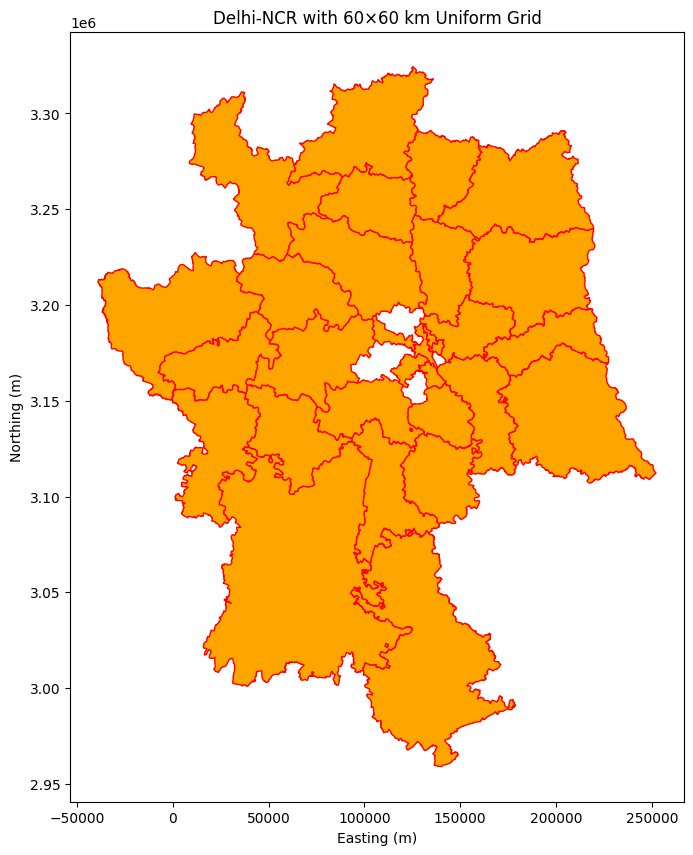

In [6]:
fig, ax = plt.subplots(figsize=(14,10))

ncr_utm.plot(ax=ax, color="orange", edgecolor="red")


plt.title("Delhi-NCR with 60×60 km Uniform Grid")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.show()

In [7]:

import os
import pandas as pd
image_folder = "/content/drive/MyDrive/rgb/"
files = os.listdir(image_folder)

records = []

for file in files:
    if file.endswith(".png"):
        try:
            lat, lon = map(float, file.replace(".png","").split("_"))
            records.append({"file": file, "lat": lat, "lon": lon})
        except:
            continue

df = pd.DataFrame(records)

print("Total images before filtering:", len(df))

Total images before filtering: 3043


In [8]:
gdf_images = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

# Reproject to UTM to match NCR
gdf_images_utm = gdf_images.to_crs(epsg=32644)

# Filter images inside NCR boundary
filtered_images = gdf_images_utm[
    gdf_images_utm.within(ncr_utm.unary_union)
]

print("Total images after filtering:", len(filtered_images))

/tmp/ipykernel_1853/472594324.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_images_utm.within(ncr_utm.unary_union)


Total images after filtering: 2965


In [9]:
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterio.windows import Window
from shapely.geometry import Point
from scipy import stats
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

In [10]:
base_path = "/content/drive/MyDrive/"
image_folder = base_path + "rgb/"

files = os.listdir(image_folder)

records = []

for file in files:
    if file.endswith(".png"):
        try:
            lat, lon = map(float, file.replace(".png","").split("_"))
            records.append({"file": file, "lat": lat, "lon": lon})
        except:
            continue

df = pd.DataFrame(records)

print("Total images:", len(df))

Total images: 3104


In [11]:
gdf_images = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

In [12]:
raster_path = base_path + "worldcover_bbox_delhi_ncr_2021.tif"
src = rasterio.open(raster_path)

print("Raster CRS:", src.crs)

Raster CRS: EPSG:4326


In [13]:
gdf_images_raster = gdf_images.to_crs(src.crs)

In [14]:
def extract_patch(row, patch_size=128):
    x, y = row.geometry.x, row.geometry.y

    row_center, col_center = src.index(x, y)
    half = patch_size // 2

    window = Window(
        col_center - half,
        row_center - half,
        patch_size,
        patch_size
    )

    patch = src.read(1, window=window)
    return patch

In [15]:
patches = []

for idx, row in gdf_images_raster.iterrows():
    try:
        patch = extract_patch(row)
        patches.append(patch)
    except:
        patches.append(None)

gdf_images_raster["patch"] = patches

In [16]:
def get_mode_class(patch):
    if patch is None:
        return None

    values = patch.flatten()
    values = values[values != 0]

    if len(values) == 0:
        return None

    return stats.mode(values, keepdims=False).mode

gdf_images_raster["esa_class"] = gdf_images_raster["patch"].apply(get_mode_class)

In [17]:
def simplify_class(code):
    if code in [10, 20, 30]:
        return "Vegetation"
    elif code == 40:
        return "Cropland"
    elif code == 50:
        return "Built-up"
    elif code == 80:
        return "Water"
    else:
        return "Others"

gdf_images_raster["label"] = gdf_images_raster["esa_class"].apply(simplify_class)

Total labeled samples: 3104
Train size: 1862
Test size: 1242


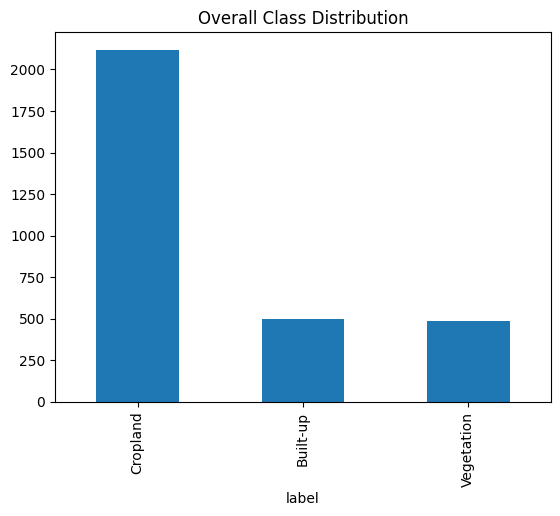

In [18]:
dataset = gdf_images_raster.dropna(subset=["label"])
print("Total labeled samples:", len(dataset))
train_df, test_df = train_test_split(
    dataset,
    test_size=0.4,
    random_state=42,
    stratify=dataset["label"]
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))
plt.figure()
dataset["label"].value_counts().plot(kind="bar")
plt.title("Overall Class Distribution")
plt.show()

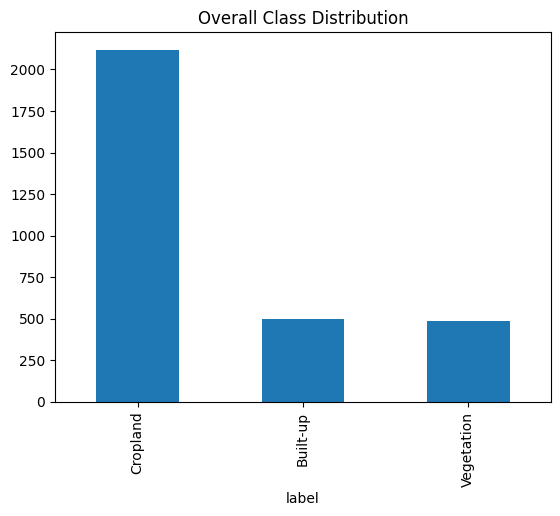

In [19]:
plt.figure()
dataset["label"].value_counts().plot(kind="bar")
plt.title("Overall Class Distribution")
plt.show()

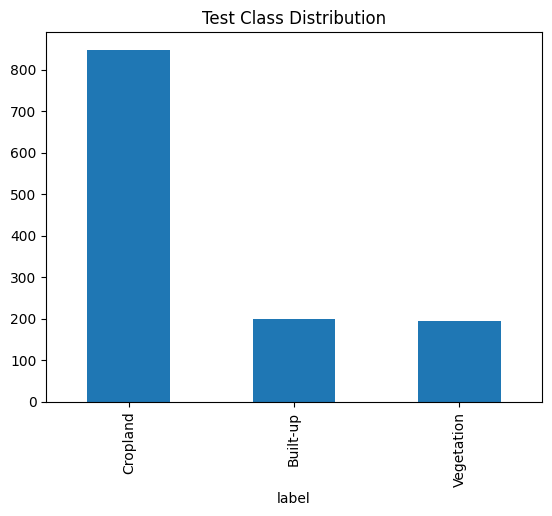

In [20]:
plt.figure()
test_df["label"].value_counts().plot(kind="bar")
plt.title("Test Class Distribution")
plt.show()

Q3

In [21]:
!pip install torch torchvision scikit-learn -q

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import numpy as np
import os
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [23]:
class_names = sorted(train_df["label"].unique())
class_to_idx = {cls:i for i, cls in enumerate(class_names)}
idx_to_class = {i:cls for cls, i in class_to_idx.items()}

train_df["label_idx"] = train_df["label"].map(class_to_idx)
test_df["label_idx"] = test_df["label"].map(class_to_idx)

num_classes = len(class_names)
print("Classes:", class_names)

Classes: ['Built-up', 'Cropland', 'Vegetation']


In [24]:
class LandUseDataset(Dataset):
    def __init__(self, dataframe, image_folder, transform=None):
        self.df = dataframe
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_folder, self.df.iloc[idx]["file"])
        image = Image.open(img_path).convert("RGB")
        label = self.df.iloc[idx]["label_idx"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [25]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [26]:
image_folder = "/content/drive/MyDrive/rgb/"

train_dataset = LandUseDataset(train_df, image_folder, transform)
test_dataset = LandUseDataset(test_df, image_folder, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s]


In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [29]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

Epoch 1/5, Loss: 23.4962
Epoch 2/5, Loss: 13.2477
Epoch 3/5, Loss: 18.6933
Epoch 4/5, Loss: 14.9400
Epoch 5/5, Loss: 8.6386


In [30]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Test Accuracy:", accuracy)
print("Test F1-score:", f1)

Test Accuracy: 0.8768115942028986
Test F1-score: 0.882326568927793


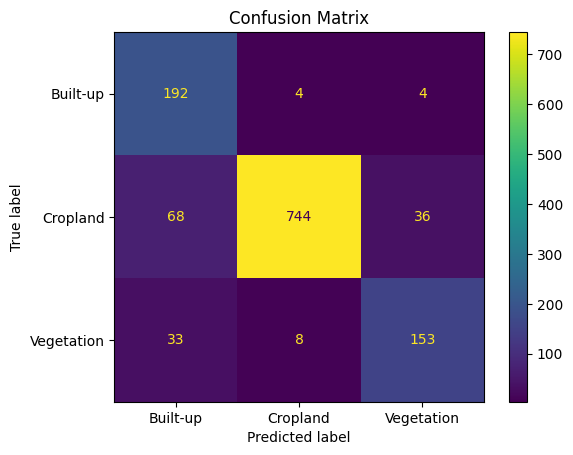

In [31]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)

disp.plot()
plt.title("Confusion Matrix")
plt.show()